In [1]:
# Giovanni: use utils.read_gbq to pull the data, it caches the data
# it takes almost the same input as pandas.read_gbq 
# see the docstrings in utils.py if in doubt
from utils import read_gbq, rename_cols
import matplotlib.pyplot as plt
from tableone import TableOne
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import os

warnings.filterwarnings("ignore")


In [2]:
# test different values here 
WINDOW_SIZE=12
OFFSET=6

In [6]:
PROCEDURES=Path("./procedures")
# PROJECT_ID=os.getenv('PROJECTID')
# PROJECT_ID="clinical-entity-extraction"
PROJECT_ID = "physio-414520" 

In [9]:
sep_df=read_gbq(PROCEDURES / "sepsis.sql",project_id=PROJECT_ID)
sep_df=sep_df.sort_values(by=['patientunitstayid'])
# 23479 uniqque patients

In [12]:
# # Transfusiuon Data
transfusion_df=read_gbq(PROCEDURES / "transfusion.sql",project_id=PROJECT_ID)
transfusion_df=transfusion_df.sort_values(by=['patientunitstayid','offset'])
transfusion_df.offset=transfusion_df.offset/60

# HGB Data
hgb_df=read_gbq(PROCEDURES / "hgb.sql",project_id=PROJECT_ID)
hgb_df=hgb_df.sort_values(by=['patientunitstayid','offset'])
hgb_df.offset=hgb_df.offset/60

# Apache Data
apache_df=read_gbq(PROCEDURES / "apache.sql",project_id=PROJECT_ID)
apache_df=apache_df.sort_values(by=['patientunitstayid'])

# Fluids Data
fluids_df=read_gbq(PROCEDURES / "fluid_balance.sql",project_id=PROJECT_ID)
fluids_df=fluids_df.sort_values(by=['patientunitstayid','transfusion_offset'])
fluids_df.transfusion_offset=fluids_df.transfusion_offset/60

# Demographic data 
demographics_df=read_gbq(PROCEDURES / "demographics.sql",project_id=PROJECT_ID)

# GI Bleeder
gb_df=read_gbq(PROCEDURES / "gb.sql",project_id=PROJECT_ID)
gb_df['gi_bleeder']=True

# Length of stay
lengthStay_df = (read_gbq(PROCEDURES / "lengthStay.sql", project_id=PROJECT_ID)
                 .sort_values(by=['patientunitstayid']))
time_columns = ['ICU_Stay', 'Time_prior_ICU', 'hospitalDischargeOffset']
lengthStay_df[time_columns] = lengthStay_df[time_columns] / 60
lengthStay_df['Total_time'] = lengthStay_df['hospitalDischargeOffset'] - lengthStay_df['Time_prior_ICU']

# # Vitals
vitals = (read_gbq(PROCEDURES / "vitals.sql", project_id=PROJECT_ID)
                 .sort_values(by=['patientunitstayid']))
vitals.intakeoutputoffset=vitals.intakeoutputoffset/60

Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|


In [13]:
# for chunk in chunk_list(ids, len(ids)//3):
#     ids_placeholder = ', '.join(map(str, ids))
#     query = open(PROCEDURES / "vitals.sql", "r").read()
#     query = query.replace("ids_placeholder", ids_placeholder)
#     vitals=pandas_gbq.read_gbq(query)
#     dataframes.append(vitals)

from tqdm import tqdm
from utils import treatment_effect
# Giovanni : utils.treatment_effect computes the average (or any function you want) HGB in window size before transfusion (treatment) as baseline_hgb(g/dl)
# and after transfusion intitiation + a OFFSET for estimating the post treatment effect

data=[]
for ix,group in tqdm(transfusion_df.groupby('patientunitstayid')):
    data.append(treatment_effect(
        group,
        hgb_df[hgb_df.patientunitstayid.isin(group.patientunitstayid)],
        WINDOW_SIZE,
        OFFSET,
        'mean')
        )

def merge_info(original, to_merge, merge_by):
    filter_merge =  to_merge[to_merge[merge_by].isin(original[merge_by].unique())]
    merged = pd.merge(original, filter_merge, how='left')
    return merged

100%|██████████| 19694/19694 [01:47<00:00, 183.34it/s]


In [14]:
df=pd.concat(data).groupby('patientunitstayid').first().reset_index() # for now we only keep the first transfusion


df=df.merge(demographics_df,on='patientunitstayid',validate='1:1')
# df.age=df.age.replace('> 89',91).astype(float)
df.age=df.age.replace('> 89', 91)
df.age=pd.to_numeric(df.age, errors='coerce')

print(df['patientunitstayid'].nunique())

df=df[df['age'] >= 18]
print('Age', df['patientunitstayid'].nunique())

# 20 patients lower than 18

df=df[~df['patientunitstayid'].isin(gb_df['patientunitstayid'].unique())]
print('GI',df['patientunitstayid'].nunique())
# GI bleeders: 469

post=df[df['post_treatment'].isna()]
df=df[df['post_treatment'].notna()]
print('post', df['patientunitstayid'].nunique())


base=df[df['baseline'].isna()]
df=df[df['baseline'].notna()]
print('baseline', df['patientunitstayid'].nunique())

19694
Age 19674
GI 19205
post 15924
baseline 13992


In [15]:
#Giovanni: nomenclature note
# df=pd.concat(data).groupby('patientunitstayid').first().reset_index() # for now we only keep the first transfusion

# df=df.merge(demographics_df,on='patientunitstayid',validate='1:1')
# # df.age=df.age.replace('> 89',91).astype(float)
# df.age=df.age.replace('> 89', 91)
# df.age=pd.to_numeric(df.age, errors='coerce')
df['age_quartile']=pd.qcut(df.age,[.0,.25,.5,.75,1.],precision=1).astype(str)

# df=df.merge(gb_df,on='patientunitstayid',how='left',validate='1:1')
# df.gi_bleeder=df.gi_bleeder.fillna(False)

# Add length of stay to df
df=merge_info(df, lengthStay_df, 'patientunitstayid')


# ---------------
# Add apache score
apache_concat=apache_df[['patientunitstayid', 'apache_score']]
apache_concat=apache_concat.drop_duplicates()
df=df.merge(apache_concat, on='patientunitstayid', how='left', validate='1:1')
# ---------------

temp=fluids_df.merge(df[['patientunitstayid','treatment_offset']],on='patientunitstayid')
temp['delta']=temp.transfusion_offset-temp.treatment_offset
temp=temp.groupby('patientunitstayid').apply(lambda data: data.sort_values(by='delta').iloc[-1,:],include_groups=True)
temp=temp.reset_index(drop=True).drop(['treatment_offset','delta','transfusion_offset'],axis=1)
df=df.merge(temp,on='patientunitstayid',how='left',validate='1:1')

df=df[df.treatment_effect.notna()] # removes patients with missing values on treatment effect
df=df[df.treatment_offset>=0] # remove patients who receives transfusion before ICU admission


df['HGB Increment (g/dL) Quartile']=pd.qcut(df.treatment_effect,[.0,.25,.5,.75,1.],precision=1).astype(str)
df['baseline_quartile']=pd.qcut(df.baseline,[.0,.25,.5,.75,1.],precision=1).astype(str)


# Vitals 
# NOTE: Please review-----
vp_temp=vitals.merge(df[['patientunitstayid', 'treatment_offset']],on='patientunitstayid')
# REMINDER: Need to change this; use something other than iloc[0:, 1:5] in case more features are added
vp_temp=vp_temp.groupby('patientunitstayid').apply(lambda data: data.iloc[0:, 1:5]
                                                   .mean(),include_groups=False)
vp_temp=vp_temp.reset_index()
df=df.merge(vp_temp,on='patientunitstayid',how='left',validate='1:1')

###########################

# print(df['patientunitstayid'].nunique())

# df=df[df['age'] >= 18]
# print('Age', df['patientunitstayid'].nunique())

# # 20 patients lower than 18

# df=df[~df['patientunitstayid'].isin(gb_df['patientunitstayid'].unique())]
# print('GI',df['patientunitstayid'].nunique())
# # GI bleeders: 469

# post=df[df['post_treatment'].isna()]
# df=df[df['post_treatment'].notna()]
# print('post', df['patientunitstayid'].nunique())


# base=df[df['baseline'].isna()]
# df=df[df['baseline'].notna()]
# print('baseline', df['patientunitstayid'].nunique())

#########################


exclude=['_window_size','_offset','aggfunc']
categorical=['gender','age_quartile','ethnicity','icu_outcome','hosp_outcome'] # Removed GI as they were excluded above
continuous=['initial_weight','treatment_effect','treatment_value','treatment_offset','baseline','netTotal',

           'Total_time', 'apache_score','SaO2', 'heartrate', 'respiration', 'bp']

In [17]:
df['has_sepsis'] = df['patientunitstayid'].isin(sep_df['patientunitstayid']).astype(int)
df.has_sepsis.value_counts()

has_sepsis
0    8877
1    2946
Name: count, dtype: int64

In [18]:
sepsis_df=df[df['has_sepsis']==1]
non_sepsis_df=df[df['has_sepsis']==0]

In [19]:
# change this to create table one for sepsis patients and non-sepsis patients
non_sepsis_t1=TableOne(non_sepsis_df,
         columns=categorical+continuous,
         categorical=categorical,
         groupby='HGB Increment (g/dL) Quartile',
         pval=True,
         )
non_sepsis_t1=rename_cols(non_sepsis_t1)
# non_sepsis_t1

In [21]:
non_sepsis_t1

Grouped by HGB Increment (g/dL) Quartile  \
                                                                                         Missing   
n                                                                                                  
gender, n (%)                          Female                                                      
                                       Male                                                        
age_quartile, n (%)                    (17.9, 55.0]                                                
                                       (55.0, 67.0]                                                
                                       (67.0, 77.0]                                                
                                       (77.0, 91.0]                                                
ethnicity, n (%)                                                                                   
                                       African American                                            
                                       Asian                                                       
                                       Caucasian                                                   
                                       Hispanic                                                    
                                       Native American                                             
                                       Other/Unknown                                               
icu_outcome, n (%)                     deceased                                                    
                                       discharged                                                  
hosp_outcome, n (%)                    deceased                                                    
                                       discharged                                                  
initial_weight, mean (SD)                                                                    382   
HGB Increment (g/dL), mean (SD)                                                                0   
Transfusion Volume (mL), mean (SD)                                                             0   
Time to Transfusion (hours), mean (SD)                                                         0   
Baseline HGB (g/dL), mean (SD)                                                                 0   
Total Fluids (ml), mean (SD)                                                                   0   
ICU Stay Length (hrs), mean (SD)                                                               0   
apache_score, mean (SD)                                                                     1355   
SaO2, mean (SD)                                                                              849   
heartrate, mean (SD)                                                                         743   
respiration, mean (SD)                                                                      1418   
bp, mean (SD)                                                                               5849   

                                                                         \
                                                                Overall   
n                                                                  8877   
gender, n (%)                          Female               4087 (46.0)   
                                       Male                 4790 (54.0)   
age_quartile, n (%)                    (17.9, 55.0]         2148 (24.2)   
                                       (55.0, 67.0]         2206 (24.9)   
                                       (67.0, 77.0]         2282 (25.7)   
                                       (77.0, 91.0]         2241 (25.2)   
ethnicity, n (%)                                               33 (0.4)   
                                       African American     1060 (11.9)   
                              

In [20]:
# change this to create table one for sepsis patients and non-sepsis patients
sepsis_t1=TableOne(sepsis_df,
         columns=categorical+continuous,
         categorical=categorical,
         groupby='HGB Increment (g/dL) Quartile',
         pval=True,
         )
sepsis_t1=rename_cols(sepsis_t1)
sepsis_t1

Grouped by HGB Increment (g/dL) Quartile  \
                                                                                         Missing   
n                                                                                                  
gender, n (%)                          Female                                                      
                                       Male                                                        
age_quartile, n (%)                    (17.9, 55.0]                                                
                                       (55.0, 67.0]                                                
                                       (67.0, 77.0]                                                
                                       (77.0, 91.0]                                                
ethnicity, n (%)                                                                                   
                                       African American                                            
                                       Asian                                                       
                                       Caucasian                                                   
                                       Hispanic                                                    
                                       Native American                                             
                                       Other/Unknown                                               
icu_outcome, n (%)                     deceased                                                    
                                       discharged                                                  
hosp_outcome, n (%)                    deceased                                                    
                                       discharged                                                  
initial_weight, mean (SD)                                                                    102   
HGB Increment (g/dL), mean (SD)                                                                0   
Transfusion Volume (mL), mean (SD)                                                             0   
Time to Transfusion (hours), mean (SD)                                                         0   
Baseline HGB (g/dL), mean (SD)                                                                 0   
Total Fluids (ml), mean (SD)                                                                   0   
ICU Stay Length (hrs), mean (SD)                                                               0   
apache_score, mean (SD)                                                                      335   
SaO2, mean (SD)                                                                              224   
heartrate, mean (SD)                                                                         190   
respiration, mean (SD)                                                                       434   
bp, mean (SD)                                                                               1929   

                                                                         \
                                                                Overall   
n                                                                  2946   
gender, n (%)                          Female               1472 (50.0)   
                                       Male                 1474 (50.0)   
age_quartile, n (%)                    (17.9, 55.0]          854 (29.0)   
                                       (55.0, 67.0]          850 (28.9)   
                                       (67.0, 77.0]          642 (21.8)   
                                       (77.0, 91.0]          600 (20.4)   
ethnicity, n (%)                                                6 (0.2)   
                                       African American      411 (14.0)   
                              

In [33]:
# EDA and Statistical Analysis for Sepsis Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Function to compare numerical features between sepsis and non-sepsis groups
def compare_groups(df, column):
    sepsis = df[df['has_sepsis'] == 1][column]
    non_sepsis = df[df['has_sepsis'] == 0][column]
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(sepsis, non_sepsis, nan_policy='omit')
    
    # Calculate standard deviations
    sepsis_std = sepsis.std()
    non_sepsis_std = non_sepsis.std()
    
    # Create formatted DataFrame with results including std dev
    results = pd.DataFrame({
        'Sepsis Mean (SD)': [f"{sepsis.mean():.2f} (±{sepsis_std:.2f})"],
        'Non-Sepsis Mean (SD)': [f"{non_sepsis.mean():.2f} (±{non_sepsis_std:.2f})"],
        'Mean Difference': [f"{(sepsis.mean() - non_sepsis.mean()):.2f}"],
        'P-value': [f"{'<0.001' if p_value < 0.001 else f'{p_value:.3f}'}"]
    })
    
    return results

# List of numerical features to analyze with readable labels
numerical_features = {
    'age': 'Age (years)',
    'initial_weight': 'Initial Weight (kg)', 
    'ICU_Stay': 'ICU Length of Stay (hours)',
    'Time_prior_ICU': 'Time Prior to ICU (hours)',
    'Total_time': 'Total Time (hours)',
    'netTotal': 'Net Fluid Balance (mL)',
    'intakeTotal': 'Total Fluid Intake (mL)',
    'outputTotal': 'Total Fluid Output (mL)',
    'treatment_effect': 'Treatment Effect',
    'baseline': 'Baseline Value'
}

# Create comparison table with improved formatting
comparison_results = pd.concat(
    [compare_groups(df, col) for col in numerical_features.keys()],
    keys=numerical_features.values()
)

# Display formatted table
print("\nComparison of Clinical Parameters Between Sepsis and Non-Sepsis Patients")
print("=" * 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)
print(comparison_results.to_string(justify='left'))
print("=" * 100)
print("\nNote: P-values <0.001 are displayed as '<0.001'")



Comparison of Clinical Parameters Between Sepsis and Non-Sepsis Patients
                             Sepsis Mean (SD)    Non-Sepsis Mean (SD) Mean Difference P-value
Age (years)                0      63.09 (±16.04)      65.70 (±15.85)    -2.61          <0.001
Initial Weight (kg)        0      81.67 (±27.46)      82.10 (±24.97)    -0.43           0.442
ICU Length of Stay (hours) 0    195.63 (±236.33)    132.10 (±174.21)    63.53          <0.001
Time Prior to ICU (hours)  0    -94.82 (±389.60)    -51.05 (±130.99)   -43.77          <0.001
Total Time (hours)         0    469.29 (±569.22)    330.92 (±423.04)   138.37          <0.001
Net Fluid Balance (mL)     0   632.21 (±1240.17)   503.87 (±1103.39)   128.34          <0.001
Total Fluid Intake (mL)    0  1153.32 (±1275.94)  1041.36 (±1237.66)   111.96          <0.001
Total Fluid Output (mL)    0    535.35 (±964.30)    554.41 (±856.32)   -19.06           0.311
Treatment Effect           0        1.48 (±1.39)        1.26 (±1.51)     0.22   

Numerical Features Comparison:
                    Sepsis Mean  Non-Sepsis Mean  Difference       P-value
age              0    63.091650        65.696744   -2.605095  1.405482e-14
initial_weight   0    81.670580        82.097154   -0.426573  4.421090e-01
ICU_Stay         0   195.633820       132.102587   63.531233  2.679326e-54
Time_prior_ICU   0   -94.823065       -51.052167  -43.770899  7.088733e-20
Total_time       0   469.294009       330.923833  138.370176  2.260206e-44
netTotal         0   632.210031       503.870425  128.339606  1.183187e-07
intakeTotal      0  1153.317583      1041.358352  111.959231  2.444532e-05
outputTotal      0   535.348948       554.406444  -19.057496  3.108940e-01
treatment_effect 0     1.478489         1.259408    0.219081  4.030980e-12
baseline         0     7.279785         7.628116   -0.348331  6.360332e-28


<Figure size 1500x1000 with 0 Axes>

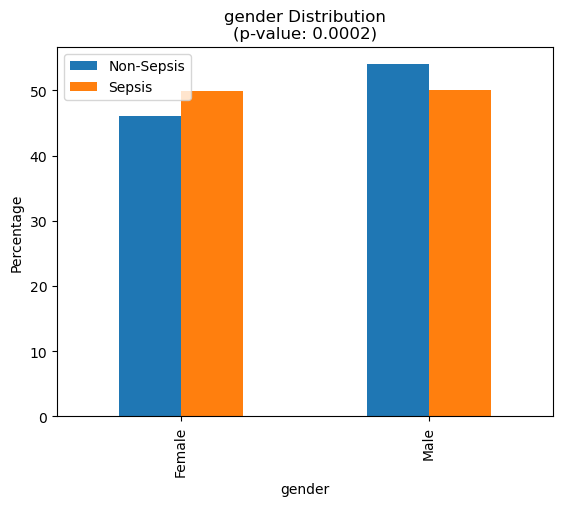

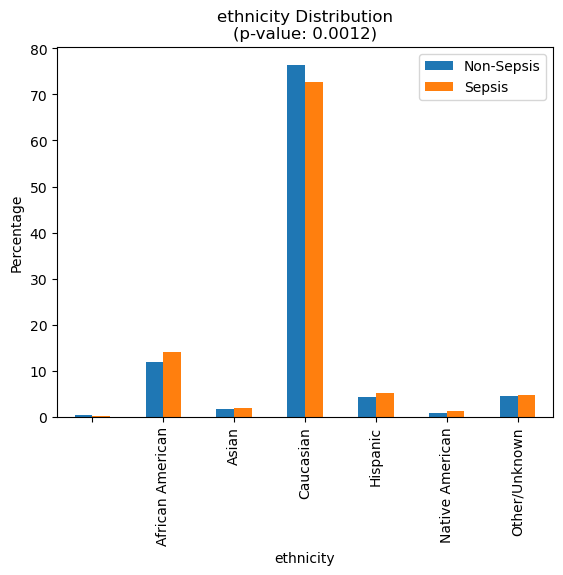

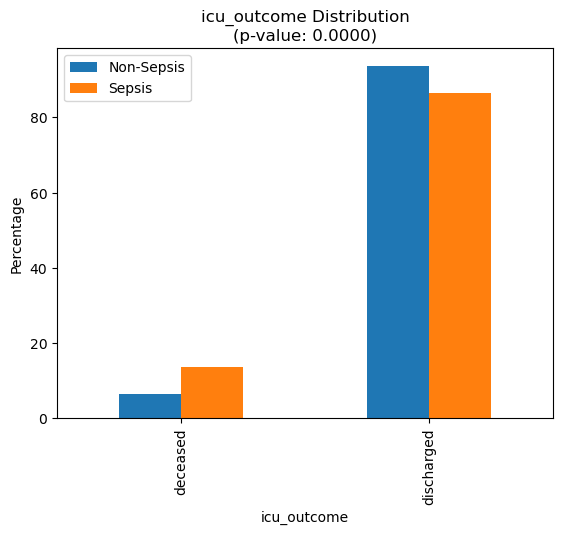

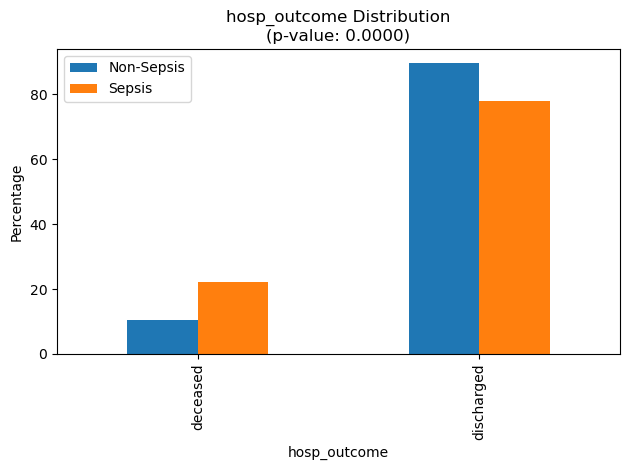

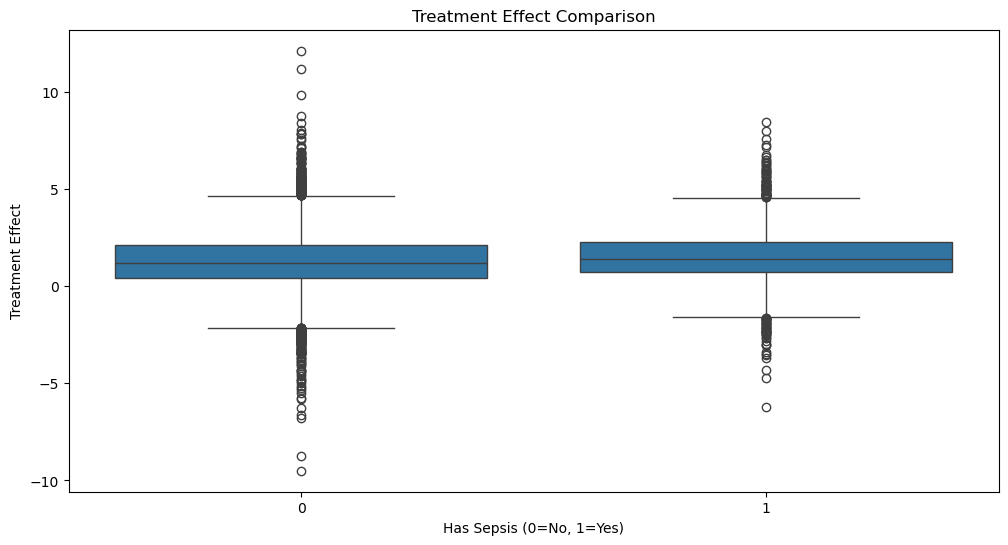


Outcome Analysis (percentages):
has_sepsis                        0          1
icu_outcome hosp_outcome                      
deceased    deceased       6.173257  13.170401
            discharged     0.146446   0.407332
discharged  deceased       4.314521   8.893415
            discharged    89.365777  77.528853

Summary Statistics:
Total patients: 11823
Sepsis patients: 2946
Non-sepsis patients: 8877
Sepsis rate: 24.92%


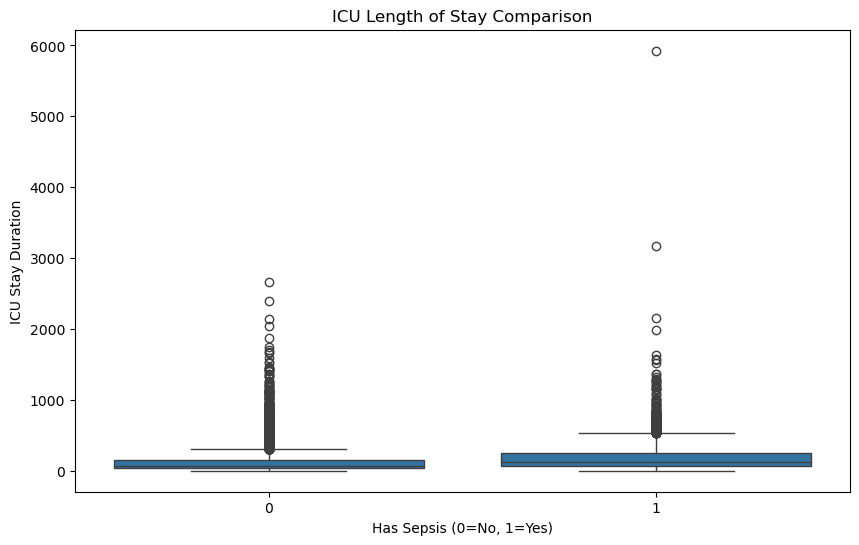

In [ ]:

# 2. Categorical features analysis
categorical_features = ['gender', 'ethnicity', 'icu_outcome', 'hosp_outcome']

def categorical_analysis(df, feature):
    contingency = pd.crosstab(df[feature], df['has_sepsis'])
    chi2, p_value = stats.chi2_contingency(contingency)[:2]
    
    # Calculate percentages
    percentages = pd.crosstab(df[feature], df['has_sepsis'], normalize='columns') * 100
    
    return contingency, p_value, percentages

# Plot categorical features
plt.figure(figsize=(15, 10))
for idx, feature in enumerate(categorical_features, 1):
    contingency, p_value, percentages = categorical_analysis(df, feature)
    
    # _=plt.subplot(2, 3, idx)
    _=percentages.plot(kind='bar')
    _=plt.title(f'{feature} Distribution\n(p-value: {p_value:.4f})')
    _=plt.xlabel(feature)
    _=plt.ylabel('Percentage')
    _=plt.legend(['Non-Sepsis', 'Sepsis'])
_=plt.tight_layout()
plt.show()

# 3. Treatment effect analysis
_=plt.figure(figsize=(12, 6))
_=sns.boxplot(x='has_sepsis', y='treatment_effect', data=df)
_=plt.title('Treatment Effect Comparison')
_=plt.xlabel('Has Sepsis (0=No, 1=Yes)')
_=plt.ylabel('Treatment Effect')
_=plt.show()

# 4. Outcome analysis
outcome_comparison = pd.crosstab([df['icu_outcome'], df['hosp_outcome']], 
                               df['has_sepsis'], 
                               normalize='columns') * 100
print("\nOutcome Analysis (percentages):")
print(outcome_comparison)

# 5. Summary statistics
print("\nSummary Statistics:")
print(f"Total patients: {len(df)}")
print(f"Sepsis patients: {df['has_sepsis'].sum()}")
print(f"Non-sepsis patients: {len(df) - df['has_sepsis'].sum()}")
print(f"Sepsis rate: {(df['has_sepsis'].mean() * 100):.2f}%")

# 6. Length of stay analysis
_=plt.figure(figsize=(10, 6))
_=sns.boxplot(x='has_sepsis', y='ICU_Stay', data=df)
plt.title('ICU Length of Stay Comparison')
plt.xlabel('Has Sepsis (0=No, 1=Yes)')
plt.ylabel('ICU Stay Duration')
plt.show()

In [ ]:

# t1_pd=t1.tableone
# with open('sepsis_table1.tex', 'w') as f:
#     f.write(t1_pd.to_latex())

In [ ]:
# t1_pd_nonsepsis=t1_nonsepsis.tableone
# with open('sepsis_table1_nonsepsis.tex', 'w') as f:
#     f.write(t1_pd_nonsepsis.to_latex())

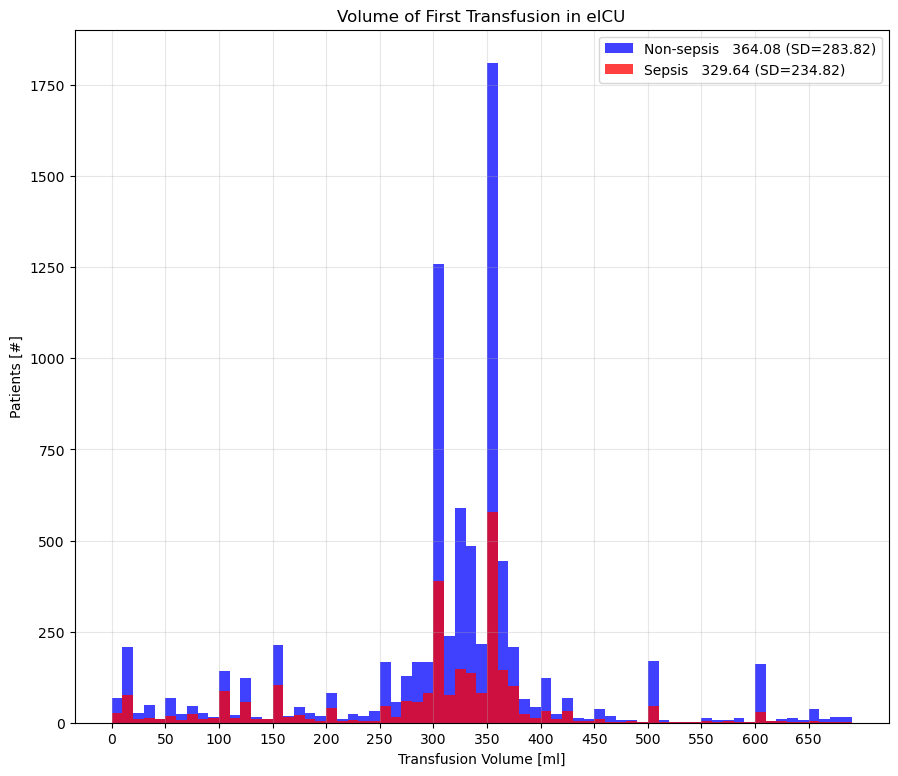

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Giovanni: this is invariant to WINDOW_SIZE and OFFSET

def labeled_plot(data:pd.Series,ax,label:str,f,**kwargs):
    mn=data.mean()
    sd=data.std()
    ulabel=f'{label}   {mn:.2f} (SD={sd:.2f})'
    return getattr(data.plot,f)(ax=ax,label=ulabel,**kwargs)

fig,ax=plt.subplots(figsize=(10.5,9))
_=labeled_plot(non_sepsis_df.treatment_value, ax,'Non-sepsis','hist',bins=np.arange(0,700,10),alpha=.75,color='Blue')
_=labeled_plot(sepsis_df.treatment_value,ax,'Sepsis','hist',bins=np.arange(0,700,10),alpha=.75, color='Red')
_=ax.set_xticks(np.arange(0,700,50))
_=ax.set_xlabel('Transfusion Volume [ml]')
_=ax.set_ylabel('Patients [#]')
_=ax.set_title('Volume of First Transfusion in eICU')
_=ax.grid(alpha=.3)
_=ax.legend()

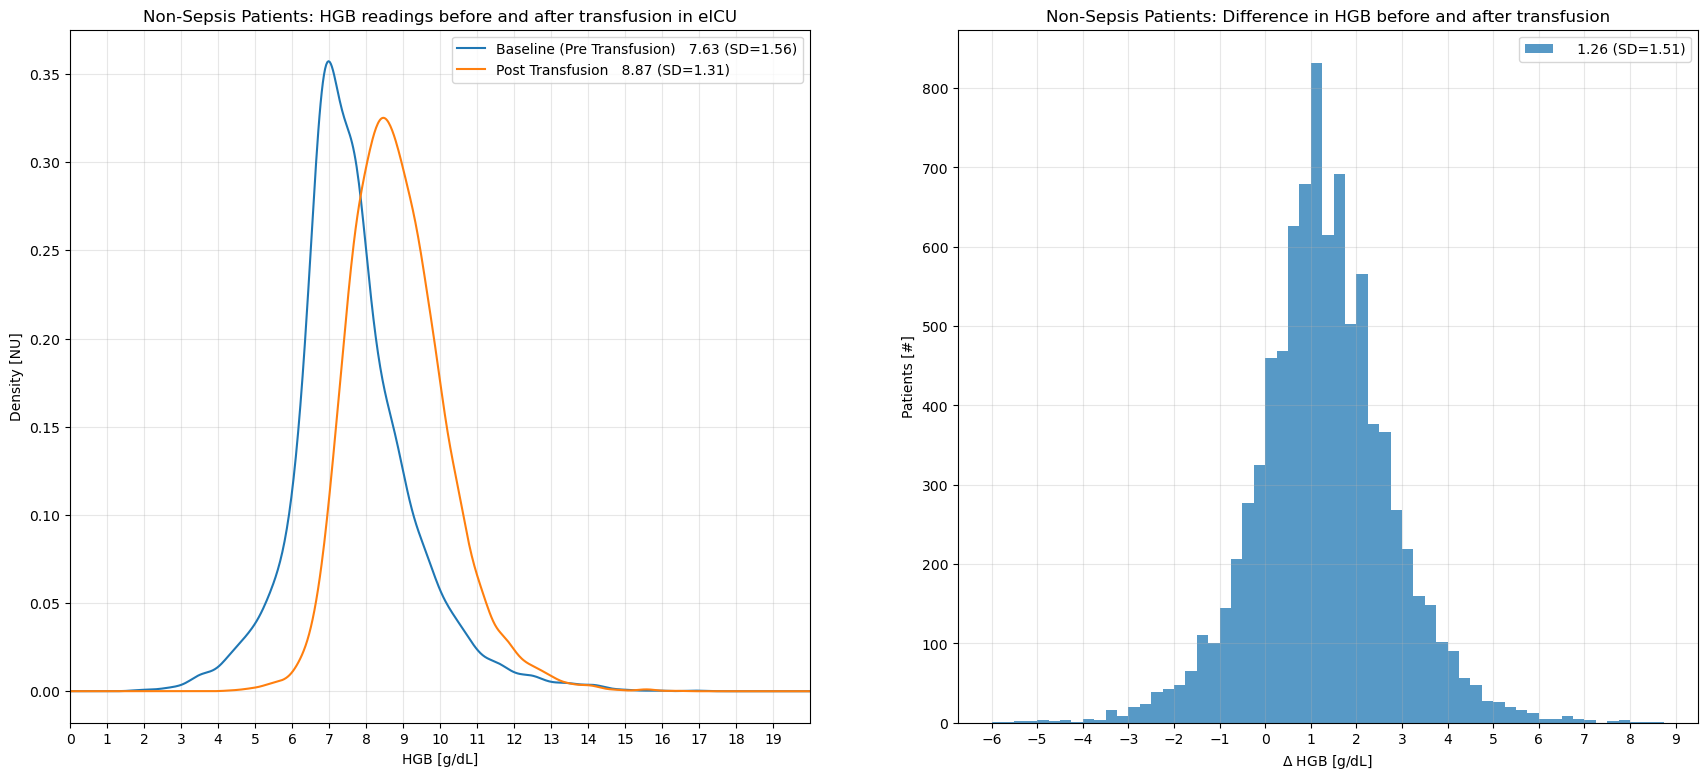

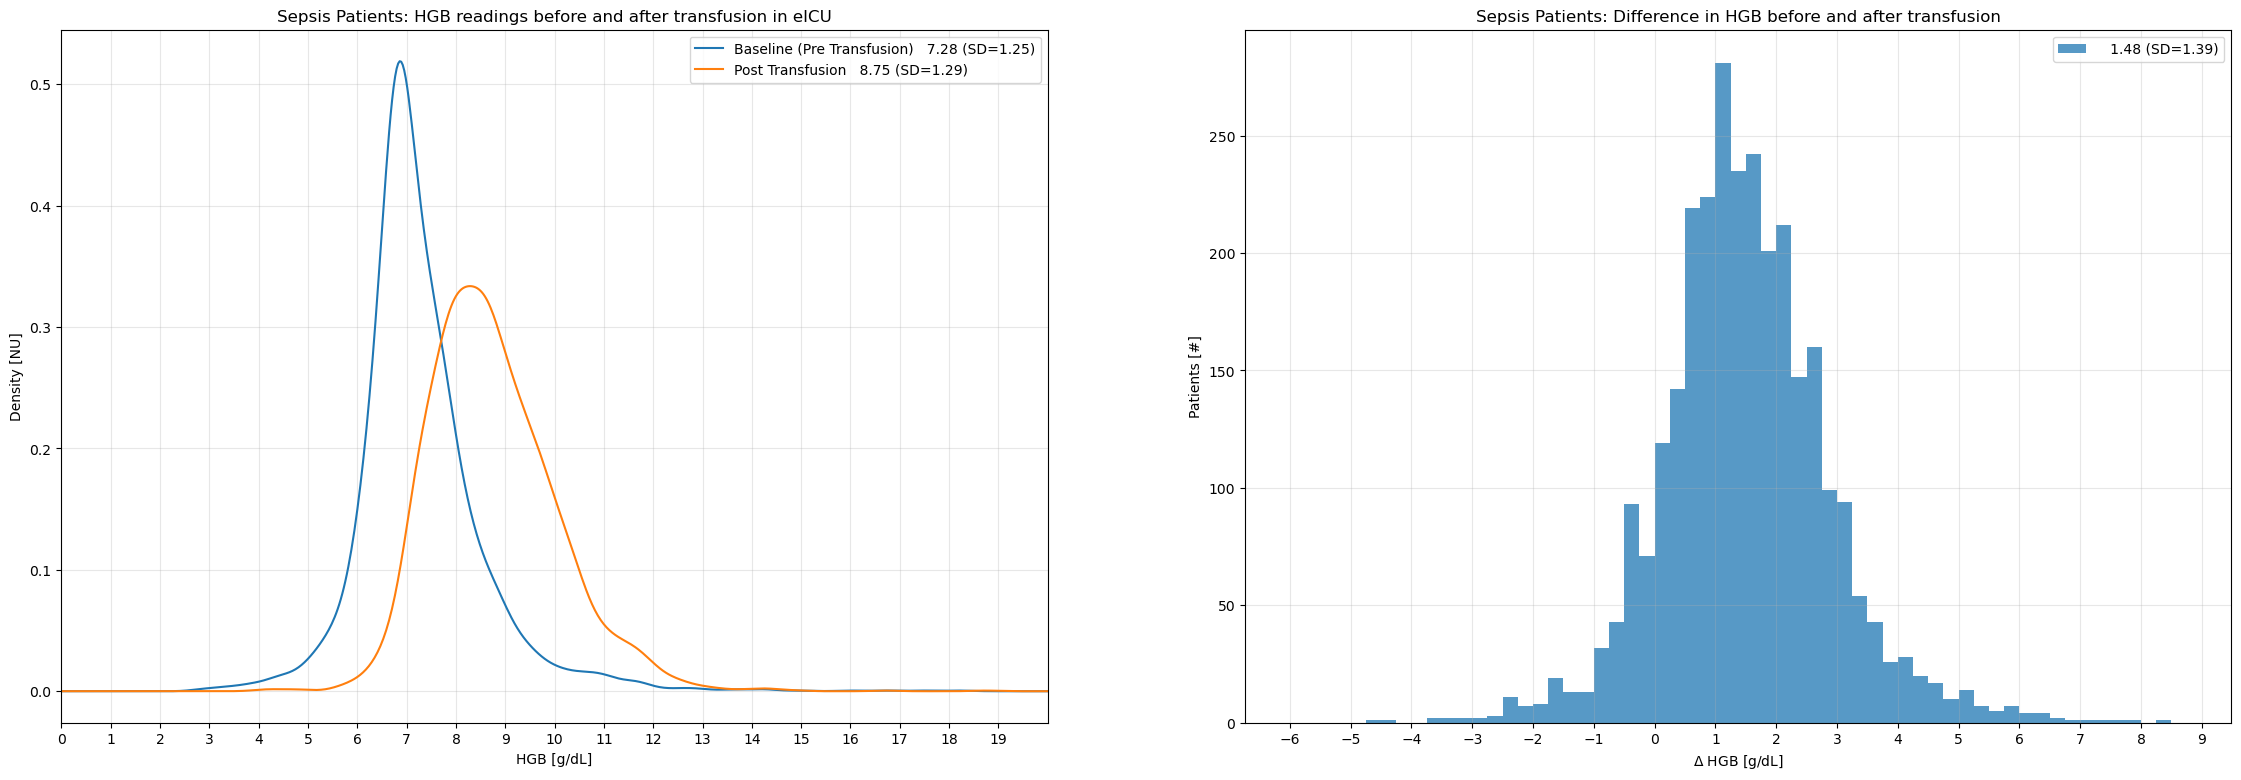

In [24]:
fig,ax=plt.subplots(1,2,figsize=(21,9))

# Non sepsis patients
_=labeled_plot(non_sepsis_df.baseline,ax=ax[0],label='Baseline (Pre Transfusion)',f='kde')
_=labeled_plot(non_sepsis_df.post_treatment,ax=ax[0],label='Post Transfusion',f='kde')

_=ax[0].legend()
_=ax[0].set_xlim([0,20])
_=ax[0].set_xticks(np.arange(0,20,1.))
_=ax[0].set_xlabel('HGB [g/dL]')
_=ax[0].set_ylabel('Density [NU]')
_=ax[0].set_title('Non-Sepsis Patients: HGB readings before and after transfusion in eICU')
_=ax[0].grid(alpha=.3)

_=labeled_plot(non_sepsis_df.treatment_effect,ax=ax[1],label='',f='hist',bins=np.arange(-6,9,.25),alpha=.75)
_=ax[1].set_xticks(np.arange(-6,10,1.))
_=ax[1].set_xlabel('$\Delta$ HGB [g/dL]')
_=ax[1].set_ylabel('Patients [#]')
_=ax[1].set_title('Non-Sepsis Patients: Difference in HGB before and after transfusion')
_=ax[1].grid(alpha=.3)
_=ax[1].legend()

# Sepsis patients
fig, ax=fig,ax=plt.subplots(1,2,figsize=(28,9))
_=labeled_plot(sepsis_df.baseline,ax=ax[0],label='Baseline (Pre Transfusion)',f='kde')
_=labeled_plot(sepsis_df.post_treatment,ax=ax[0],label='Post Transfusion',f='kde')

_=ax[0].legend()
_=ax[0].set_xlim([0,20])
_=ax[0].set_xticks(np.arange(0,20,1.))
_=ax[0].set_xlabel('HGB [g/dL]')
_=ax[0].set_ylabel('Density [NU]')
_=ax[0].set_title('Sepsis Patients: HGB readings before and after transfusion in eICU')
_=ax[0].grid(alpha=.3)

_=labeled_plot(sepsis_df.treatment_effect,ax=ax[1],label='',f='hist',bins=np.arange(-6,9,.25),alpha=.75)
_=ax[1].set_xticks(np.arange(-6,10,1.))
_=ax[1].set_xlabel('$\Delta$ HGB [g/dL]')
_=ax[1].set_ylabel('Patients [#]')
_=ax[1].set_title('Sepsis Patients: Difference in HGB before and after transfusion')
_=ax[1].grid(alpha=.3)
_=ax[1].legend()

In [25]:
# Note for Hashem: I bet you can improve this by a lot (but keep interpretability)
from sklearn.linear_model import Ridge
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
# from crlearn.evaluation import crossvalidate_regression
from sklearn.metrics import r2_score,root_mean_squared_error



to_censor=['post_treatment','treatment_effect','icu_outcome','hosp_outcome']
outcome=['treatment_effect']
features=['baseline','age','gender','ethnicity','initial_weight','treatment_value','treatment_offset','netTotal']
categorical=['gender','ethnicity']
continuous=[val for val in features if val not in categorical]

X,y=sepsis_df[features],sepsis_df[outcome]

cnt_processor=Pipeline([('impute',SimpleImputer()),('scaling',StandardScaler())])
cat_processor=Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('ohe',OneHotEncoder(drop='if_binary',sparse_output=False,min_frequency=20))]) 
processor=ColumnTransformer([
    ('categorical',cat_processor,categorical),
    ('continuous',cnt_processor,continuous),
])
model=Pipeline([('processor',processor),('regressor',Ridge(random_state=0))])
cv=RepeatedKFold(n_splits=10,n_repeats=10)

def tracing_func(model):
    coef=np.squeeze(model[-1].coef_)
    fcat=model[0]['categorical'][1].get_feature_names_out(categorical)
    return pd.Series(coef,index=[*fcat,*continuous])

In [26]:
def tracing_func(model):
    # Get the last model step coefficients (assumes it's linear and has coef_)
    coef = np.squeeze(model[-1].coef_)
    
    # Access the 'categorical' features from the ColumnTransformer
    fcat = model[0].named_transformers_['categorical'].get_feature_names_out(categorical)
    
    # Return a Series with coefficients and feature names
    return pd.Series(coef, index=[*fcat, *continuous])

In [27]:
trace=[]
scores=[]
scoring=[r2_score,root_mean_squared_error]
for train,test in cv.split(X,y):
    model=model.fit(X.iloc[train],y.iloc[train])

    y_pred=model.predict(X.iloc[test])
    scores.append([root_mean_squared_error(y.iloc[test],y_pred),r2_score(y.iloc[test],y_pred)])
    trace.append(tracing_func(model))

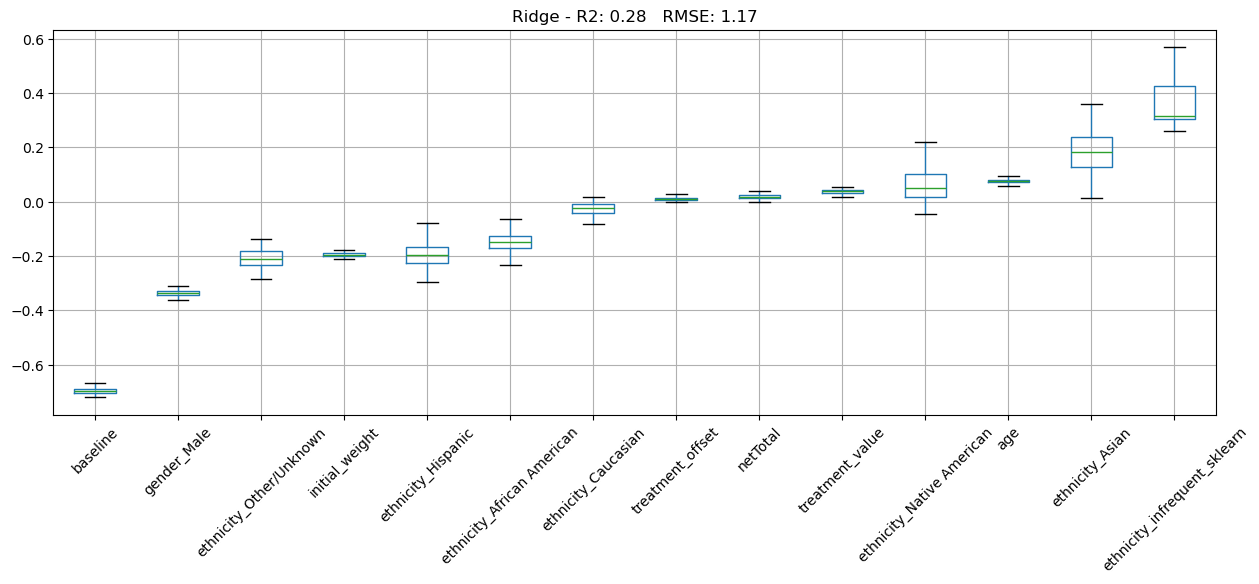

In [28]:
scores=pd.DataFrame(scores,columns=['rmse','r2'])
traces=pd.concat(trace,axis=1).T
traces=traces[traces.mean().sort_values().index]

# traces, scores=train_ridge(model, False)

fig,ax=plt.subplots(figsize=(15,5))
_=traces.boxplot(showfliers=False,rot=45,ax=ax)
_=ax.set_title(f'Ridge - R2: {scores.r2.mean():.2f}   RMSE: {scores.rmse.mean():.2f}')
plt.savefig('sepsis_features.png', dpi=300)

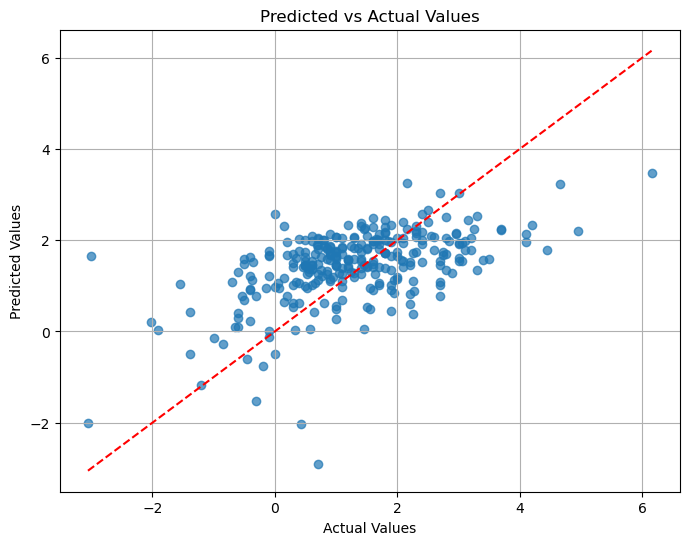

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(y.iloc[test], y_pred, alpha=0.7, label='Actual')
# plt.scatter(y.iloc[test], alpha=0.7, label='Predicted', color='red')
plt.plot([min(y.iloc[test]['treatment_effect']), max(y.iloc[test]['treatment_effect'])], [min(y.iloc[test]['treatment_effect']), max(y.iloc[test]['treatment_effect'])], color='red', linestyle='--')  # Line of perfect prediction
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.grid(True)
plt.savefig('PCA_Ridge_plot.png', dpi=300)
plt.show()